In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import re

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison_across_cutoffs(results_file):
    """Plot all models together comparing performance across different cutoffs, split by Before/After Matching"""
    df = pd.read_csv(results_file)
    
    models = df['model_name'].unique()
    cutoffs = sorted(df['cutoff_value'].unique())
    metrics = ['recall', 'precision', 'f1', 'auc']
    dataset_labels = df['dataset_name'].unique()

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    linestyles = {'Before Matching': '-', 'After Matching': '--'}

    # Map dataset_labels to matching status
    def get_matching_status(dataset):
        if "Before" in dataset:
            return "Before Matching"
        elif "After" in dataset:
            return "After Matching"
        else:
            return "Before Matching"  # Default

    for j, metric in enumerate(metrics):
        ax = axes[j]
        for i, model in enumerate(models):
            # Only add legend once per model
            model_label_added = False
            for d, dataset in enumerate(dataset_labels):
                model_data = df[(df['model_name'] == model) & (df['dataset_name'] == dataset)]
                cutoff_means = []
                cutoff_stds = []
                for cutoff in cutoffs:
                    cutoff_data = model_data[model_data['cutoff_value'] == cutoff]
                    if not cutoff_data.empty and metric in cutoff_data.columns:
                        mean_val = cutoff_data[metric].mean()
                        std_val = cutoff_data[metric].std()
                        cutoff_means.append(mean_val)
                        cutoff_stds.append(std_val if not pd.isna(std_val) else 0)
                    else:
                        cutoff_means.append(0)
                        cutoff_stds.append(0)
                matching_status = get_matching_status(dataset)
                if not model_label_added:
                    ax.errorbar(
                        cutoffs, cutoff_means, yerr=cutoff_stds, 
                        marker='o', linewidth=2, capsize=5,
                        color=colors[i % len(colors)], 
                        linestyle=linestyles[matching_status],
                        label=model
                    )
                    model_label_added = True
                else:
                    ax.errorbar(
                        cutoffs, cutoff_means, yerr=cutoff_stds, 
                        marker='o', linewidth=2, capsize=5,
                        color=colors[i % len(colors)], 
                        linestyle=linestyles[matching_status],
                        label=None
                    )
        ax.set_xlabel('Cutoff Value ($)')
        ax.set_ylabel(metric.title())
        ax.set_title(f'All Models - {metric.title()}')
        ax.legend(title="Model (solid=dashed: before/after matching)")
        ax.grid(True, alpha=0.3)
    
    labels = ["50k", "75k", "100k", "200k", "300k", "400k", "500k"]
    plt.xticks(cutoffs, labels) 
    plt.tight_layout()
    plt.savefig(f'all_models_performance_across_cutoffs.png', dpi=300, bbox_inches='tight')
    plt.show()
def extract_lower_bound(bin_str):
    """Extract the lower bound from a bin string for sorting"""
    if pd.isna(bin_str) or bin_str == 'Overall':
        return -1  # Put Overall first if it exists, but we'll filter it out anyway
    # Look for pattern like "0.00-0.10"
    match = re.search(r'(\d+\.\d+)-', str(bin_str))
    return float(match.group(1)) if match else 0.0

In [20]:
def plot_cutoff_comparison_by_model(results_file, metrics):
    """Plot all models for each cutoff separately, excluding 'Overall' bin, split by Before/After Matching"""
    df = pd.read_csv(results_file)
    
    # Filter out Overall bin
    df = df[df['bin'] != 'Overall']
    
    # Sort bins by numerical order
    #unique_bins = sorted(df['bin'].unique(), key=extract_lower_bound)
    unique_bins = sorted(df['bin'].unique())
    cutoffs = sorted(df['cutoff_value'].unique())
    models = [model for model in df['model_name'].unique() if model.startswith("Gradient")]

    dataset_labels = df['dataset_name'].unique()
    
    fig, axes = plt.subplots(len(cutoffs), len(metrics), figsize=(20, 5*len(cutoffs)))
    if len(cutoffs) == 1:
        axes = axes.reshape(1, -1)
    
    colors = ['blue', 'orange','green', 'red', 'purple', 'brown'] 
    linestyles = {'Before Matching': '-', 'After Matching': '--'}

    for i, cutoff in enumerate(cutoffs):
        cutoff_data = df[df['cutoff_value'] == cutoff]
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            model_plotted = set()  # Track which models have already been labeled in legend

            for m, model in enumerate(models):
                for d, dataset in enumerate(dataset_labels):
                    # Determine matching status from dataset name
                    if "Before" in dataset:
                        matching_status = "Before Matching"
                    elif "After" in dataset:
                        matching_status = "After Matching"
                    else:
                        matching_status = "Before Matching"  # Default if no info

                    model_cutoff_data = cutoff_data[
                        (cutoff_data['model_name'] == model) &
                        (cutoff_data['dataset_name'] == dataset)
                    ]
                    if not model_cutoff_data.empty and metric in model_cutoff_data.columns:
                        bin_to_index = {bin_name: idx for idx, bin_name in enumerate(unique_bins)}
                        model_cutoff_data = model_cutoff_data[model_cutoff_data['bin'].isin(unique_bins)].copy()
                        model_cutoff_data['bin_order'] = model_cutoff_data['bin'].map(bin_to_index)
                        model_cutoff_data = model_cutoff_data.sort_values('bin_order')
                        x_values = [bin_to_index[bin_name] for bin_name in model_cutoff_data['bin']]
                        
                        # Only add legend label the first time for each model
                        label = model if model not in model_plotted else None
                        ax.plot(
                            x_values, model_cutoff_data[metric], 
                            marker='o', linewidth=2,
                            color=colors[m % len(colors)],
                            linestyle=linestyles[matching_status],
                            label=label
                        )
                        if model not in model_plotted:
                            model_plotted.add(model)
            
            ax.set_xlabel('Risk Bin')
            ax.set_ylabel(metric.title())
            ax.set_title(f'Cutoff ${cutoff:,} - {metric.title()}')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'cutoff_comparison_by_model.png', dpi=300, bbox_inches='tight')
    plt.show()

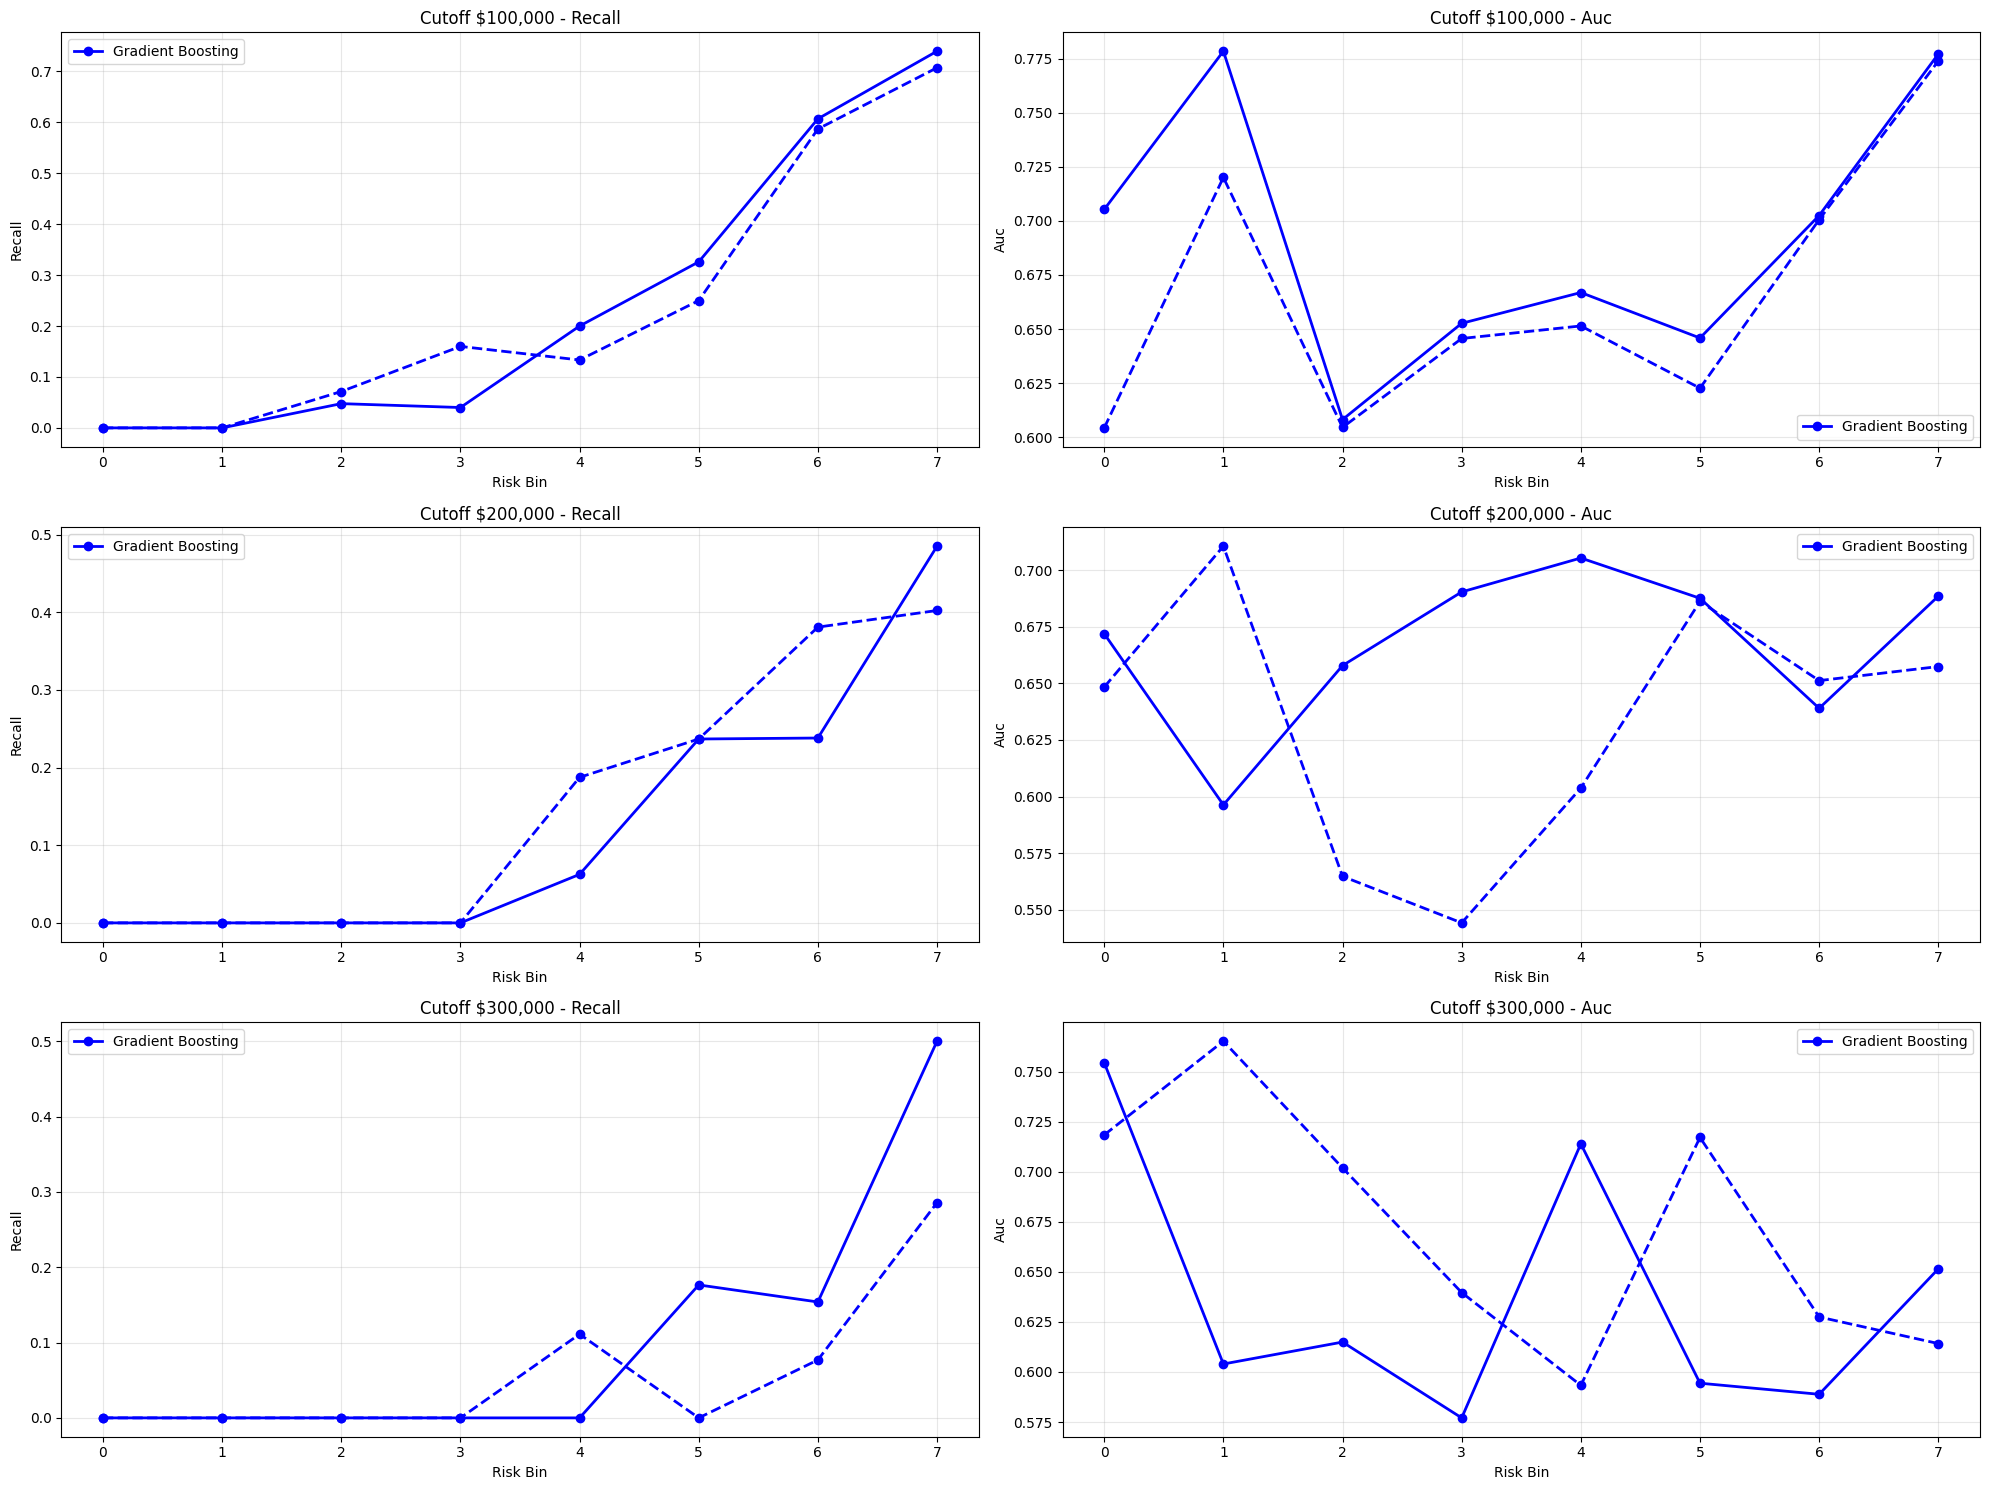

In [21]:
##results_file = "../output_0902_adherence_income_info/pipeline_results.csv"
results_file = "../test_pipeline_output/pipeline_results.csv"
metrics = ['recall','auc']
plot_cutoff_comparison_by_model(results_file,metrics)

## Thorough analysis of differences between training stratifier on low- vs. high-stage

=== BINNING STRATEGY COMPARISON ANALYSIS ===

New approach: 6956 patients
Old approach: 6956 patients
Patient overlap: 4982 patients
Merged dataset for comparison: 4982 patients

2. BIN TRANSITION ANALYSIS


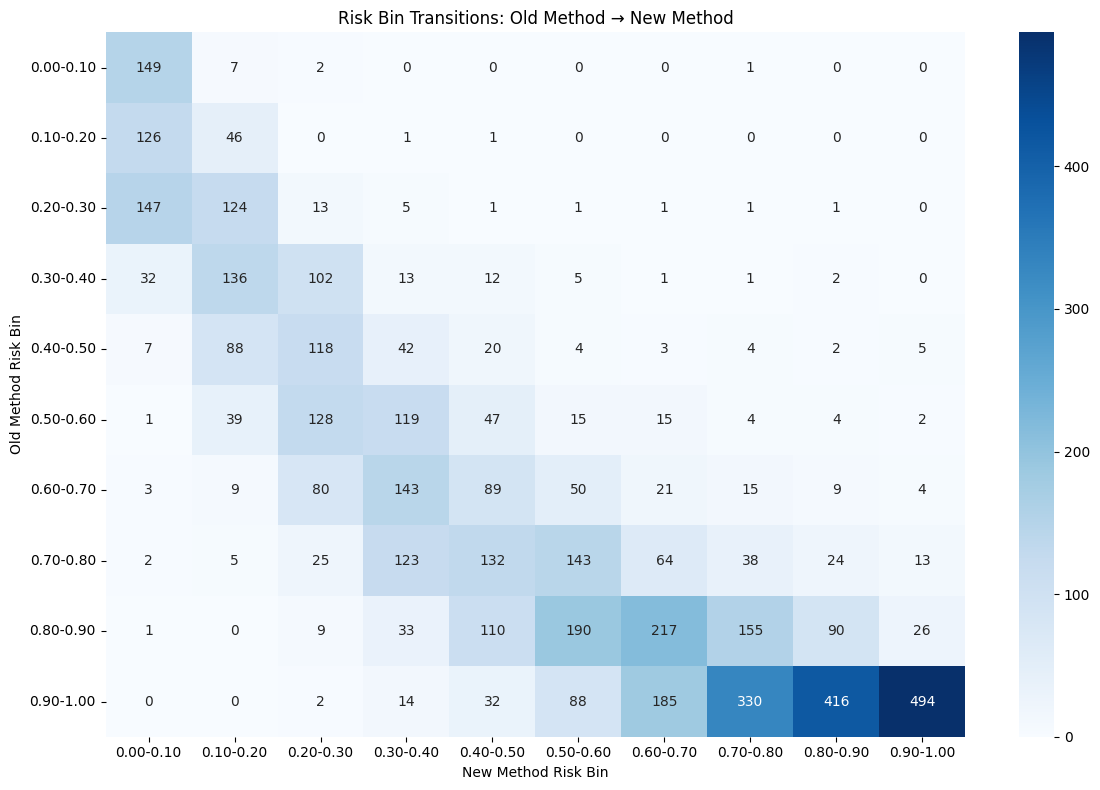


3. HIGHEST RISK BIN DIFFERENCES
Highest risk bin - New: 0.90-1.00, Old: 0.90-1.00

Patients highest risk in NEW but not OLD: 50
Patients highest risk in OLD but not NEW: 1067

4. PATIENT FEATURE COMPARISON

=== FEATURE COMPARISON: Patients High-Risk in NEW but not OLD ===
AGEGRP: Mean=4.200, Median=4.000
SEX: Mean=1.340, Median=1.000
REGION: Mean=2.340, Median=3.000
stage_2017: Mean=4.060, Median=4.000
annual_cost17: Mean=315200.612, Median=340110.966
highcost_gt_50000: Mean=0.740, Median=1.000
highcost_gt_75000: Mean=0.700, Median=1.000
highcost_gt_100000: Mean=0.680, Median=1.000
highcost_gt_200000: Mean=0.640, Median=1.000
highcost_gt_300000: Mean=0.540, Median=1.000
highcost_gt_400000: Mean=0.420, Median=0.000
highcost_gt_500000: Mean=0.200, Median=0.000
has_Hypertension: Mean=0.880, Median=1.000
has_Type_2_Diabetes: Mean=0.560, Median=1.000
has_Anemia: Mean=0.480, Median=0.000
has_Hyperlipidemia: Mean=0.540, Median=1.000
has_Acute_Kidney_Failure: Mean=0.240, Median=0.000
util_201

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def analyze_binning_differences(new_file, old_file):
    """
    Comprehensive analysis comparing two binning strategies
    """
    # Load data
    new_df = pd.read_csv(new_file)
    old_df = pd.read_csv(old_file)
    
    print(f"New approach: {len(new_df)} patients")
    print(f"Old approach: {len(old_df)} patients")
    
    # Check patient overlap
    new_ids = set(new_df['ENROLID'])
    old_ids = set(old_df['ENROLID'])
    overlap_ids = new_ids.intersection(old_ids)
    
    print(f"Patient overlap: {len(overlap_ids)} patients")
    
    # Create merged dataset for overlapping patients
    new_subset = new_df[new_df['ENROLID'].isin(overlap_ids)].copy()
    old_subset = old_df[old_df['ENROLID'].isin(overlap_ids)].copy()
    
    # Merge on ENROLID to compare bins
    merged = pd.merge(
        new_subset[['ENROLID', 'risk_bin', 'risk_score']],
        old_subset[['ENROLID', 'risk_bin', 'risk_score']],
        on='ENROLID',
        suffixes=('_new', '_old')
    )
    
    print(f"Merged dataset for comparison: {len(merged)} patients")
    
    return new_df, old_df, merged

def examine_risk_bin_distributions(new_df, old_df):
    """
    Compare risk bin distributions between methods
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # New approach bins
    new_bins = new_df['risk_bin'].value_counts().sort_index()
    new_bins.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title('New Approach: Risk Bin Distribution')
    ax1.set_xlabel('Risk Bin')
    ax1.set_ylabel('Patient Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # Old approach bins
    old_bins = old_df['risk_bin'].value_counts().sort_index()
    old_bins.plot(kind='bar', ax=ax2, color='lightcoral')
    ax2.set_title('Old Approach: Risk Bin Distribution')
    ax2.set_xlabel('Risk Bin')
    ax2.set_ylabel('Patient Count')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return new_bins, old_bins

def analyze_bin_transitions(merged):
    """
    Analyze how patients move between bins across methods
    """
    # Create transition matrix
    transition_matrix = pd.crosstab(
        merged['risk_bin_old'], 
        merged['risk_bin_new'],
        margins=True
    )

    # Visualize transition matrix
    plt.figure(figsize=(12, 8))
    # Remove margins for heatmap
    transition_viz = transition_matrix.iloc[:-1, :-1]
    sns.heatmap(transition_viz, annot=True, fmt='d', cmap='Blues')
    plt.title('Risk Bin Transitions: Old Method → New Method')
    plt.xlabel('New Method Risk Bin')
    plt.ylabel('Old Method Risk Bin')
    plt.tight_layout()
    plt.show()
    
    return transition_matrix

def identify_highest_risk_differences(merged, new_df, old_df):
    """
    Focus on highest risk bin differences
    """
    # Identify highest risk bins in each method
    new_highest = merged['risk_bin_new'].max()
    old_highest = merged['risk_bin_old'].max()
    
    print(f"Highest risk bin - New: {new_highest}, Old: {old_highest}")
    
    # Find patients who were highest risk in one method but not the other
    high_risk_new_not_old = merged[
        (merged['risk_bin_new'] == new_highest) & 
        (merged['risk_bin_old'] != old_highest)
    ]
    
    high_risk_old_not_new = merged[
        (merged['risk_bin_old'] == old_highest) & 
        (merged['risk_bin_new'] != new_highest)
    ]
    
    print(f"\nPatients highest risk in NEW but not OLD: {len(high_risk_new_not_old)}")
    print(f"Patients highest risk in OLD but not NEW: {len(high_risk_old_not_new)}")
    
    return high_risk_new_not_old, high_risk_old_not_new

def compare_patient_features(high_risk_new_not_old, high_risk_old_not_new, new_df, old_df):
    """
    Compare features of patients classified differently in highest risk bins
    """
    if len(high_risk_new_not_old) == 0 and len(high_risk_old_not_new) == 0:
        print("No patients classified differently in highest risk bins")
        return
    
    # Get full patient data for these groups
    new_high_ids = set(high_risk_new_not_old['ENROLID'])
    old_high_ids = set(high_risk_old_not_new['ENROLID'])
    
    new_high_patients = new_df[new_df['ENROLID'].isin(new_high_ids)]
    old_high_patients = old_df[old_df['ENROLID'].isin(old_high_ids)]
    
    # Define key features to compare
    key_features = [
        'AGEGRP', 'SEX', 'REGION', 'stage_2017', 'annual_cost17', "highcost_gt_50000", "highcost_gt_75000", 
        "highcost_gt_100000", "highcost_gt_200000","highcost_gt_300000",
        "highcost_gt_400000","highcost_gt_500000",
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'util_2017'
    ]
    
    # Compare means for continuous variables
    print("\n=== FEATURE COMPARISON: Patients High-Risk in NEW but not OLD ===")
    if len(new_high_patients) > 0:
        for feature in key_features:
            if feature in new_high_patients.columns:
                mean_val = new_high_patients[feature].mean()
                median_val = new_high_patients[feature].median()
                print(f"{feature}: Mean={mean_val:.3f}, Median={median_val:.3f}")
    
    print("\n=== FEATURE COMPARISON: Patients High-Risk in OLD but not NEW ===")
    if len(old_high_patients) > 0:
        for feature in key_features:
            if feature in old_high_patients.columns:
                mean_val = old_high_patients[feature].mean()
                median_val = old_high_patients[feature].median()
                print(f"{feature}: Mean={mean_val:.3f}, Median={median_val:.3f}")
    
    return new_high_patients, old_high_patients

def visualize_risk_score_distributions(merged):
    """
    Compare risk score distributions between methods
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Risk scores by method
    axes[0,0].hist(merged['risk_score_new'], bins=50, alpha=0.7, color='skyblue', label='New')
    axes[0,0].set_title('New Method: Risk Score Distribution')
    axes[0,0].set_xlabel('Risk Score')
    axes[0,0].set_ylabel('Frequency')
    
    axes[0,1].hist(merged['risk_score_old'], bins=50, alpha=0.7, color='lightcoral', label='Old')
    axes[0,1].set_title('Old Method: Risk Score Distribution')
    axes[0,1].set_xlabel('Risk Score')
    axes[0,1].set_ylabel('Frequency')
    
    # Scatter plot comparing risk scores
    axes[1,0].scatter(merged['risk_score_old'], merged['risk_score_new'], alpha=0.5)
    axes[1,0].plot([0, 1], [0, 1], 'r--', label='Perfect Agreement')
    axes[1,0].set_xlabel('Old Method Risk Score')
    axes[1,0].set_ylabel('New Method Risk Score')
    axes[1,0].set_title('Risk Score Correlation')
    axes[1,0].legend()
    
    # Risk score difference
    risk_diff = merged['risk_score_new'] - merged['risk_score_old']
    axes[1,1].hist(risk_diff, bins=50, color='purple', alpha=0.7)
    axes[1,1].set_xlabel('Risk Score Difference (New - Old)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Risk Score Differences')
    axes[1,1].axvline(x=0, color='red', linestyle='--', label='No Difference')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    correlation = merged['risk_score_new'].corr(merged['risk_score_old'])
    print(f"\nRisk Score Correlation between methods: {correlation:.4f}")

# Main analysis function
def run_complete_analysis(new_file='matched_train_df_new_approach..csv', 
                         old_file='matched_train_df_old_approach..csv'):
    """
    Run the complete binning comparison analysis
    """
    print("=== BINNING STRATEGY COMPARISON ANALYSIS ===\n")
    
    # 1. Load and basic comparison
    new_df, old_df, merged = analyze_binning_differences(new_file, old_file)
    
    # 3. Transition analysis
    print("\n2. BIN TRANSITION ANALYSIS")
    transition_matrix = analyze_bin_transitions(merged)
    
    # 4. Highest risk differences
    print("\n3. HIGHEST RISK BIN DIFFERENCES")
    high_risk_new_not_old, high_risk_old_not_new = identify_highest_risk_differences(merged, new_df, old_df)
    
    # 5. Feature comparison
    print("\n4. PATIENT FEATURE COMPARISON")
    new_high_patients, old_high_patients = compare_patient_features(
        high_risk_new_not_old, high_risk_old_not_new, new_df, old_df
    )
    
    # 6. Risk score distributions
    #print("\n5. RISK SCORE ANALYSIS")
    #visualize_risk_score_distributions(merged)
    
    
    return {
        'new_df': new_df,
        'old_df': old_df, 
        'merged': merged,
        'transition_matrix': transition_matrix,
        'high_risk_differences': {
            'new_not_old': high_risk_new_not_old,
            'old_not_new': high_risk_old_not_new
        }
    }

# Run complete analysis
new_df = "../output_0902_adherence_income_info/matched_train_df.csv"
old_df = "../output_0902_adherence_income_stratifier_on_lowstage/matched_train_df.csv"
results = run_complete_analysis(new_df,old_df)



=== COMPARATIVE BINARY FEATURE ANALYSIS ===

=== BINARY FEATURE ANALYSIS - NEW APPROACH ===

1. HIGH-COST INDICATOR PERCENTAGES BY RISK BIN:

Risk Bin 0.00-0.10 (n=716):
----------------------------------------
highcost_gt_50000: 7/716 (1.0%)
highcost_gt_75000: 2/716 (0.3%)
highcost_gt_100000: 0/716 (0.0%)
highcost_gt_200000: 0/716 (0.0%)
highcost_gt_300000: 0/716 (0.0%)
highcost_gt_400000: 0/716 (0.0%)
highcost_gt_500000: 0/716 (0.0%)

Risk Bin 0.10-0.20 (n=702):
----------------------------------------
highcost_gt_50000: 10/702 (1.4%)
highcost_gt_75000: 3/702 (0.4%)
highcost_gt_100000: 2/702 (0.3%)
highcost_gt_200000: 1/702 (0.1%)
highcost_gt_300000: 0/702 (0.0%)
highcost_gt_400000: 0/702 (0.0%)
highcost_gt_500000: 0/702 (0.0%)

Risk Bin 0.20-0.30 (n=704):
----------------------------------------
highcost_gt_50000: 33/704 (4.7%)
highcost_gt_75000: 13/704 (1.8%)
highcost_gt_100000: 11/704 (1.6%)
highcost_gt_200000: 1/704 (0.1%)
highcost_gt_300000: 1/704 (0.1%)
highcost_gt_400000: 0/70

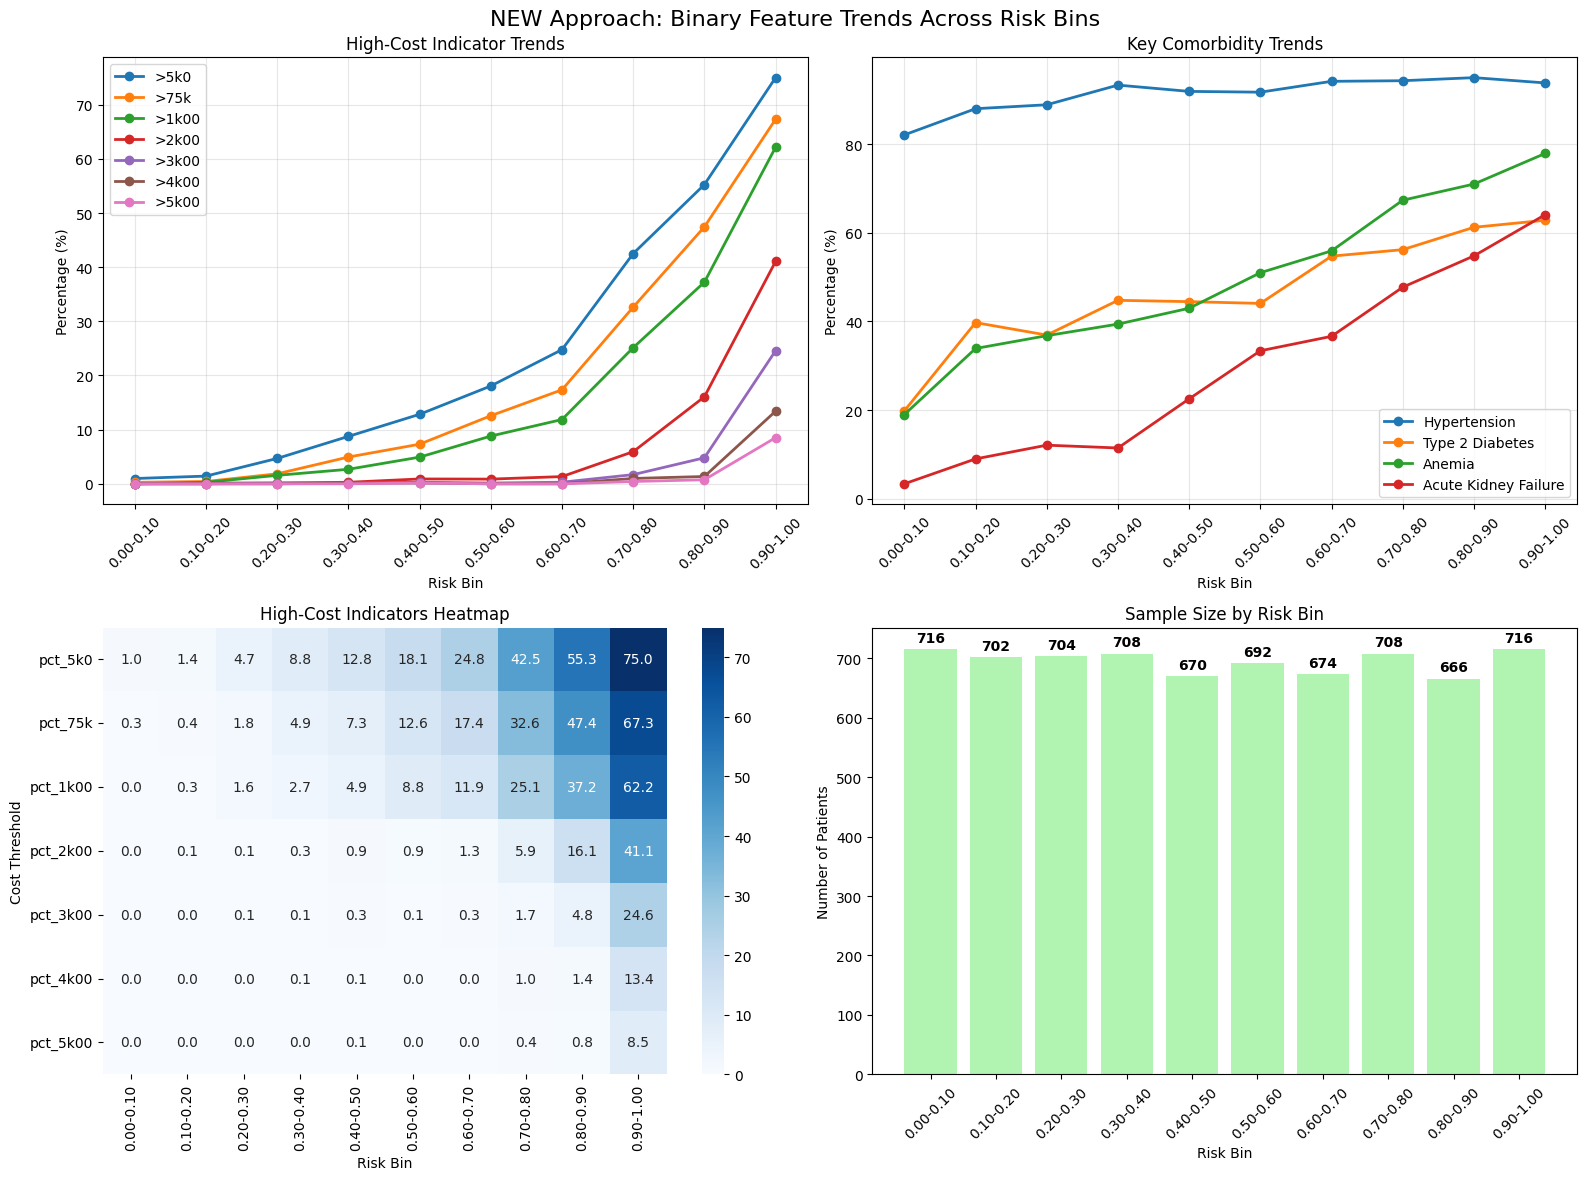

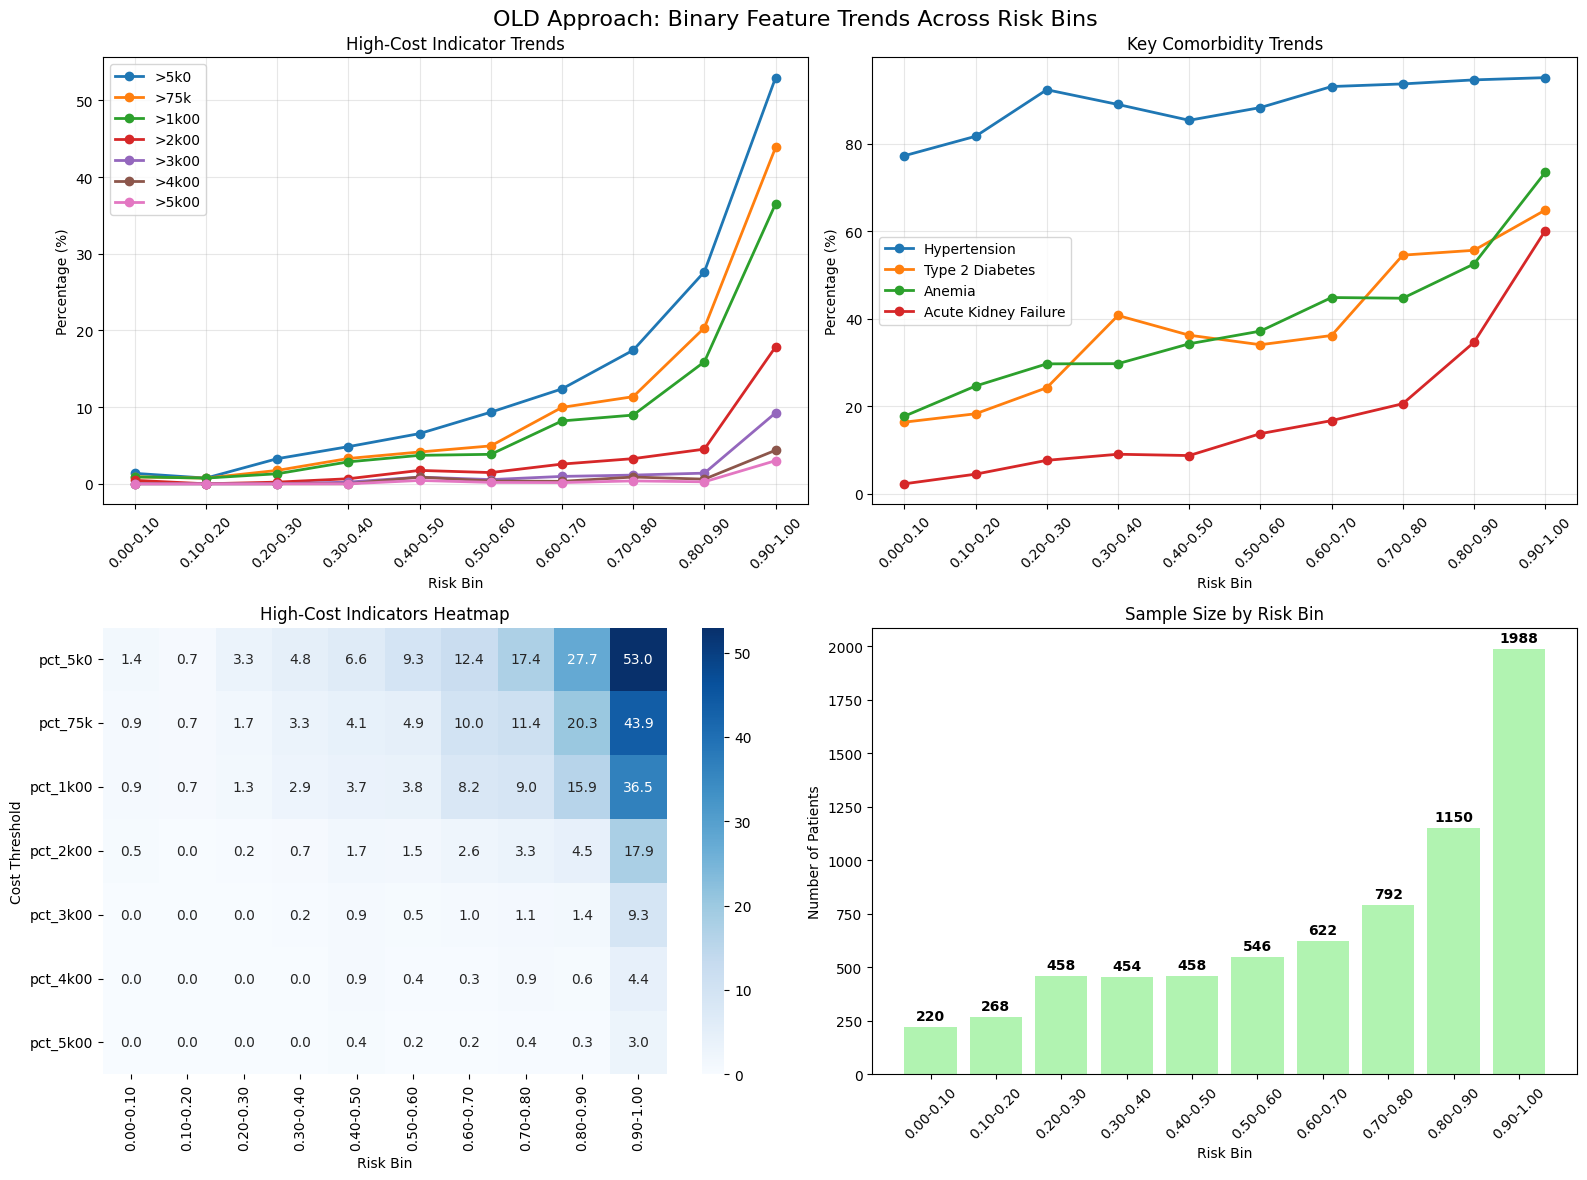


=== DIRECT COMPARISON: HIGHEST RISK BIN (0.90-1.00) ===
Sample sizes: New=716, Old=1988

High-cost indicator comparison:
>5k0: New=75.0%, Old=53.0%, Diff=+22.0%
>75k: New=67.3%, Old=43.9%, Diff=+23.5%
>1k00: New=62.2%, Old=36.5%, Diff=+25.6%
>2k00: New=41.1%, Old=17.9%, Diff=+23.2%
>3k00: New=24.6%, Old=9.3%, Diff=+15.3%
>4k00: New=13.4%, Old=4.4%, Diff=+9.0%
>5k00: New=8.5%, Old=3.0%, Diff=+5.5%

NEW APPROACH VALIDATION:

=== RISK STRATIFICATION VALIDATION ===

OLD APPROACH VALIDATION:

=== RISK STRATIFICATION VALIDATION ===

=== SUMMARY INSIGHTS ===
1. Check the percentage tables to see how high-cost indicators distribute
2. Review the trend plots to see if risk bins properly stratify outcomes
3. Compare discrimination ratios to assess which approach better separates risk levels
4. Higher correlation coefficients indicate better risk stratification


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_binary_features_by_bin(df, approach_name=""):
    """
    Analyze percentage of binary features (especially high-cost indicators) by risk bin
    """
    
    # Identify binary high-cost features
    highcost_features = [col for col in df.columns if 'highcost_gt_' in col]
    
    # Identify other binary clinical features
    clinical_binary_features = [
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism',
        'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 
        'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea'
    ]
    
    # Filter to only include features that exist in the dataset
    highcost_features = [f for f in highcost_features if f in df.columns]
    clinical_binary_features = [f for f in clinical_binary_features if f in df.columns]
    
    print(f"=== BINARY FEATURE ANALYSIS - {approach_name.upper()} APPROACH ===\n")
    
    # Get unique risk bins and sort them
    bins = sorted(df['risk_bin'].unique(), key=lambda x: float(x.split('-')[0]) if '-' in str(x) else 0)
    
    # 1. High-cost feature analysis
    print("1. HIGH-COST INDICATOR PERCENTAGES BY RISK BIN:")
    print("=" * 80)
    
    highcost_results = []
    
    for bin_name in bins:
        bin_data = df[df['risk_bin'] == bin_name]
        n_patients = len(bin_data)
        
        print(f"\nRisk Bin {bin_name} (n={n_patients}):")
        print("-" * 40)
        
        bin_result = {'bin': bin_name, 'n_patients': n_patients}
        
        for feature in highcost_features:
            if feature in bin_data.columns:
                count = bin_data[feature].sum()
                percentage = (count / n_patients * 100) if n_patients > 0 else 0
                print(f"{feature}: {count}/{n_patients} ({percentage:.1f}%)")
                
                # Extract threshold from feature name for results
                threshold = feature.replace('highcost_gt_', '').replace('000', 'k')
                bin_result[f'pct_{threshold}'] = percentage
        
        highcost_results.append(bin_result)
    
    # 2. Clinical feature analysis
    print(f"\n\n2. CLINICAL COMORBIDITY PERCENTAGES BY RISK BIN:")
    print("=" * 80)
    
    clinical_results = []
    
    for bin_name in bins:
        bin_data = df[df['risk_bin'] == bin_name]
        n_patients = len(bin_data)
        
        print(f"\nRisk Bin {bin_name} (n={n_patients}):")
        print("-" * 40)
        
        bin_result = {'bin': bin_name, 'n_patients': n_patients}
        
        for feature in clinical_binary_features:
            if feature in bin_data.columns:
                count = bin_data[feature].sum()
                percentage = (count / n_patients * 100) if n_patients > 0 else 0
                feature_clean = feature.replace('has_', '').replace('_', ' ')
                print(f"{feature_clean}: {count}/{n_patients} ({percentage:.1f}%)")
                bin_result[feature] = percentage
        
        clinical_results.append(bin_result)
    
    return pd.DataFrame(highcost_results), pd.DataFrame(clinical_results)

def visualize_binary_feature_trends(highcost_df, clinical_df, approach_name=""):
    """
    Create visualizations showing how binary feature percentages change across risk bins
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{approach_name} Approach: Binary Feature Trends Across Risk Bins', fontsize=16)
    
    # 1. High-cost indicator trends
    ax1 = axes[0, 0]
    cost_columns = [col for col in highcost_df.columns if col.startswith('pct_')]
    
    x_positions = range(len(highcost_df))
    x_labels = highcost_df['bin']
    
    for col in cost_columns:
        if col in highcost_df.columns:
            threshold = col.replace('pct_', '')
            ax1.plot(x_positions, highcost_df[col], marker='o', linewidth=2, label=f'>{threshold}')
    
    ax1.set_title('High-Cost Indicator Trends')
    ax1.set_xlabel('Risk Bin')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(x_labels, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Key comorbidities
    ax2 = axes[0, 1]
    key_comorbidities = ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Acute_Kidney_Failure']
    
    for feature in key_comorbidities:
        if feature in clinical_df.columns:
            label = feature.replace('has_', '').replace('_', ' ')
            ax2.plot(x_positions, clinical_df[feature], marker='o', linewidth=2, label=label)
    
    ax2.set_title('Key Comorbidity Trends')
    ax2.set_xlabel('Risk Bin')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(x_labels, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. High-cost indicator heatmap
    ax3 = axes[1, 0]
    cost_matrix = highcost_df.set_index('bin')[cost_columns].T
    
    sns.heatmap(cost_matrix, annot=True, fmt='.1f', cmap='Blues', ax=ax3)
    ax3.set_title('High-Cost Indicators Heatmap')
    ax3.set_xlabel('Risk Bin')
    ax3.set_ylabel('Cost Threshold')
    
    # 4. Sample sizes by bin
    ax4 = axes[1, 1]
    ax4.bar(x_positions, highcost_df['n_patients'], color='lightgreen', alpha=0.7)
    ax4.set_title('Sample Size by Risk Bin')
    ax4.set_xlabel('Risk Bin')
    ax4.set_ylabel('Number of Patients')
    ax4.set_xticks(x_positions)
    ax4.set_xticklabels(x_labels, rotation=45)
    
    # Add sample size labels on bars
    for i, v in enumerate(highcost_df['n_patients']):
        ax4.text(i, v + max(highcost_df['n_patients']) * 0.01, str(v), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def compare_binary_features_between_approaches(new_file, old_file):
    """
    Compare binary feature percentages between new and old approaches
    """
    
    # Load data
    new_df = pd.read_csv(new_file)
    old_df = pd.read_csv(old_file)
    
    print("=== COMPARATIVE BINARY FEATURE ANALYSIS ===\n")
    
    # Analyze each approach
    new_highcost, new_clinical = analyze_binary_features_by_bin(new_df, "NEW")
    old_highcost, old_clinical = analyze_binary_features_by_bin(old_df, "OLD")
    
    # Visualize each approach
    visualize_binary_feature_trends(new_highcost, new_clinical, "NEW")
    visualize_binary_feature_trends(old_highcost, old_clinical, "OLD")
    
    # Direct comparison for highest risk bins
    print(f"\n=== DIRECT COMPARISON: HIGHEST RISK BIN (0.90-1.00) ===")
    
    new_highest = new_highcost[new_highcost['bin'] == '0.90-1.00']
    old_highest = old_highcost[old_highcost['bin'] == '0.90-1.00']
    
    if len(new_highest) > 0 and len(old_highest) > 0:
        print(f"Sample sizes: New={new_highest.iloc[0]['n_patients']}, Old={old_highest.iloc[0]['n_patients']}")
        print("\nHigh-cost indicator comparison:")
        
        cost_features = [col for col in new_highest.columns if col.startswith('pct_')]
        for feature in cost_features:
            if feature in new_highest.columns and feature in old_highest.columns:
                new_val = new_highest.iloc[0][feature]
                old_val = old_highest.iloc[0][feature]
                diff = new_val - old_val
                
                threshold = feature.replace('pct_', '')
                print(f">{threshold}: New={new_val:.1f}%, Old={old_val:.1f}%, Diff={diff:+.1f}%")
    
    return new_highcost, new_clinical, old_highcost, old_clinical

def calculate_risk_validation_metrics(highcost_df):
    """
    Calculate how well the risk stratification predicts actual high-cost outcomes
    """
    
    print(f"\n=== RISK STRATIFICATION VALIDATION ===")
    
    # Focus on key thresholds
    key_thresholds = ['pct_50k', 'pct_100k', 'pct_200k']
    
    for threshold in key_thresholds:
        if threshold in highcost_df.columns:
            print(f"\n{threshold.replace('pct_', '').upper()} Threshold Validation:")
            
            # Calculate trend (should increase with risk bin)
            values = highcost_df[threshold].values
            trend = np.corrcoef(range(len(values)), values)[0, 1]
            
            print(f"Correlation with risk bin: {trend:.3f}")
            
            # Calculate range
            min_val = values.min()
            max_val = values.max()
            range_val = max_val - min_val
            
            print(f"Range: {min_val:.1f}% to {max_val:.1f}% (span: {range_val:.1f}%)")
            
            # Calculate discrimination (highest vs lowest bin)
            discrimination = values[-1] / values[0] if values[0] > 0 else float('inf')
            print(f"Discrimination ratio (highest/lowest): {discrimination:.2f}x")

# Main execution function
def run_binary_feature_analysis(new_file='matched_train_df_new_approach..csv', 
                               old_file='matched_train_df_old_approach..csv'):
    """
    Run complete binary feature analysis for both approaches
    """
    
    # Compare both approaches
    new_highcost, new_clinical, old_highcost, old_clinical = compare_binary_features_between_approaches(new_file, old_file)
    
    # Validation metrics for both approaches
    print(f"\nNEW APPROACH VALIDATION:")
    calculate_risk_validation_metrics(new_highcost)
    
    print(f"\nOLD APPROACH VALIDATION:")
    calculate_risk_validation_metrics(old_highcost)
    
    return {
        'new_highcost': new_highcost,
        'new_clinical': new_clinical,
        'old_highcost': old_highcost,
        'old_clinical': old_clinical
    }

# Example usage
if __name__ == "__main__":
    results = run_binary_feature_analysis(new_df,old_df)
    
    print(f"\n=== SUMMARY INSIGHTS ===")
    print("1. Check the percentage tables to see how high-cost indicators distribute")
    print("2. Review the trend plots to see if risk bins properly stratify outcomes")
    print("3. Compare discrimination ratios to assess which approach better separates risk levels")
    print("4. Higher correlation coefficients indicate better risk stratification")

In [16]:
import numpy as np
import plotly.express as px
df_binned = pd.read_csv("../output_0902_adherence_income_info/matched_train_df.csv")
bins = sorted(df_binned['risk_bin'].unique(), key=lambda x: float(x.split('-')[0]))   # already ordered
df_binned["true_class"] = (df_binned["stage_2017"] > 3).astype(int)
# For actual costs
df_binned["log_annual_cost17"] = np.log1p(df_binned["annual_cost17"])

fig = px.histogram(
    df_binned,
    x="log_annual_cost17",
    color="true_class",
    labels={
        "log_annual_cost17": "Log(1 + Actual Annual Cost 2017)",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Log-Transformed True 2018 Cost by Stage Group (after Matching)",
    nbins=50,
    barmode="overlay",
    height=500, width=800
)
tick_vals = np.log1p([0, 1000, 5000, 10000, 50000,100000,500000,1000000])
tick_labels = [str(x) for x in [0, 1000, 5000, 10000, 50000,100000,500000,1000000]]

fig.update_xaxes(
    tickvals=tick_vals,
    ticktext=tick_labels,
    title_text="Annual Cost 2017"
)
fig.show()

fig = px.histogram(
    df_binned,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted Risk Score",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)
fig.show()


In [14]:
import numpy as np
import plotly.express as px
df_binned = pd.read_csv("matched_train_df.csv")
bins = sorted(df_binned['risk_bin'].unique(), key=lambda x: float(x.split('-')[0]))   # already ordered
df_binned["true_class"] = (df_binned["stage_2017"] > 3).astype(int)
# For actual costs
df_binned["log_annual_cost17"] = np.log1p(df_binned["annual_cost17"])

fig = px.histogram(
    df_binned,
    x="log_annual_cost17",
    color="true_class",
    labels={
        "log_annual_cost17": "Log(1 + Actual Annual Cost 2017)",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Log-Transformed True 2018 Cost by Stage Group (after Matching)",
    nbins=50,
    barmode="overlay",
    height=500, width=800
)
tick_vals = np.log1p([0, 1000, 5000, 10000, 50000,100000,500000,1000000])
tick_labels = [str(x) for x in [0, 1000, 5000, 10000, 50000,100000,500000,1000000]]

fig.update_xaxes(
    tickvals=tick_vals,
    ticktext=tick_labels,
    title_text="Annual Cost 2017"
)
fig.show()

fig = px.histogram(
    df_binned,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted Risk Score",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)
fig.show()


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log1p

